In [ ]:
import sys; sys.path.append('../..')
from abstraction.tokenize import *
from abstraction.book_history import standardize_format
import pandas as pd
import plotnine as p9
from tqdm import tqdm
p9.options.dpi = 300
p9.options.figure_size=(10,6)

In [ ]:
df = pd.read_csv('/Volumes/diderot/lltk_data/corpora/estc/metadata.csv').fillna('')
df_fmt = pd.DataFrame(df['book_dimensions'].apply(standardize_format).tolist())
df = df.join(df_fmt)
df

In [ ]:
from collections import Counter
counter = Counter()
stopwords = get_stopwords()

def tokz(x):
    return [x for x in tokenize_agnostic(x.lower()) if x.strip() and x[0].isalpha()]

for title,subtitle in tqdm(zip(df.title,df.title_sub), total=len(df)):
    if title:
        counter.update(tokz(title))
    if subtitle:
        counter.update(tokz(subtitle))

In [ ]:
s=pd.Series(counter).sort_values(ascending=False)
# s=s[s>=10]

In [ ]:
sdf = pd.DataFrame({'count':s}).rename_axis('word')
sdf['rank'] = sdf['count'].rank(method='min', ascending=False)
sdf

In [ ]:
genres = ['novel','novels','romance','romances','tale','tales','story','stories']

sdf.loc[genres].sort_values('count', ascending=False)

In [ ]:
sdf[sdf['count']>=100]

In [ ]:
words = '\n'.join(sdf[sdf['count']>=100].index.tolist())

In [ ]:
# with open('words2.txt', 'w') as f:
#     f.write(words)


In [ ]:
# !open .

In [ ]:
# !pip install openpyxl

In [221]:
# genredf = pd.read_csv('../data/fields/genre_terms.csv').set_index('word')
genredf = pd.read_excel('../data/fields/genre_terms.xlsx').set_index('word')
genredf = genredf[genredf.is_fiction=='y']
genredf = genredf.join(sdf, how='left').sort_values('count', ascending=False)
# genredf.sort_values('count', ascending=False).head(100)
# genredf.sort_values('count', ascending=False).head(100).to_csv('genre_counts_sorted.csv', index=False)
# !open .
# genredf

In [222]:
o = []
for i,row in tqdm(df.iterrows(), total=len(df)):
    toks = tokz(row.title + ' ' + row.title_sub)
    for t in toks:
        if t in genredf.index:
            outd = {
                'id_estc':row.id_estc,
                'author':row.author,
                'title':row.title,
                'title_sub':row.title_sub,
                'year':row.year,
                'book_dimensions':row.book_dimensions,
                'format_std':row.format_std,
                'word':t,
            }
            o.append(outd)
odf = pd.DataFrame(o)
# odf

100%|██████████| 481711/481711 [00:26<00:00, 18054.16it/s]


In [314]:
genredf2 = genredf.copy()
genredf2['rank'] = genredf2['count'].rank(method='min', ascending=False)
genredf2.columns = [f'genre_{c}' for c in genredf2.columns]
odf2 = odf.merge(genredf2, on='word', how='left')
# odf2
odf2['year'] = pd.to_numeric(odf2['year'], errors='coerce')
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['decade'] = df['year'] // 10 * 10
odf2['decade'] = odf2['year'] // 10 * 10

In [224]:
# genredf2

In [ ]:
# pd.options.display.max_colwidth = 1000
# odf2[odf2['genre_lemma'] == 'sketch'][['title','title_sub','format_std']]

In [300]:
# figdf = odf2.groupby(['genre_genre','year']).size().reset_index(name='count')
# figdf['year_count'] = figdf.year.map(year_counts)
# figdf['pct'] = figdf['count'] / figdf['year_count'] * 100
# figdf['year'] = pd.to_numeric(figdf['year'], errors='coerce')
# figdf = figdf.query('1500 <= year < 1800')
# figdf = figdf.dropna()
# figdf = figdf.sort_values(['genre_genre', 'year'])
# figdf['pct_rollavg'] = (
#     figdf.groupby('genre_genre')['pct']
#     .transform(lambda x: x.rolling(window=10, min_periods=0, center=True).mean())
# )
# figdf['count_rollavg'] = (
#     figdf.groupby('genre_genre')['count']
#     .transform(lambda x: x.rolling(window=10, min_periods=0, center=True).mean())
# )
# figdf

In [364]:
import numpy as np
yearcol = 'decade'
figdf = (
    odf2.groupby(['genre_genre', yearcol])
    .size()
    .reset_index(name='count')
)

year_counts = (
    pd.to_numeric(odf2[yearcol], errors='coerce')
    .dropna()
    .astype(int)
    .value_counts()
)

# Clean/filter years first
figdf[yearcol] = pd.to_numeric(figdf[yearcol], errors='coerce')
figdf = figdf.query(f'1500 <= {yearcol} < 1800').dropna(subset=[yearcol])
figdf[yearcol] = figdf[yearcol].astype(int)

# Build full genre x year grid and fill missing counts with 0
years = pd.Index(range(1500, 1800), name=yearcol)
genres = pd.Index(sorted(odf2['genre_genre'].dropna().unique()), name='genre_genre')
full_index = pd.MultiIndex.from_product([genres, years], names=['genre_genre', yearcol])

figdf = (
    figdf.set_index(['genre_genre', yearcol])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

# Year totals and percentages
figdf['year_count'] = figdf[yearcol].map(year_counts).fillna(0)
figdf['pct'] = np.where(
    figdf['year_count'] > 0,
    figdf['count'] / figdf['year_count'] * 100,
    0.0
)

figdf = figdf.sort_values(['genre_genre', yearcol])

figdf['pct_rollavg'] = (
    figdf.groupby('genre_genre')['pct']
    .transform(lambda x: x.rolling(window=25, min_periods=0, center=True).mean())
)

figdf['count_rollavg'] = (
    figdf.groupby('genre_genre')['count']
    .transform(lambda x: x.rolling(window=25, min_periods=0, center=True).mean())
)

figdf['count'].sum()

np.int64(67743)

In [365]:
figdf.groupby('genre_genre')['count'].sum().sort_values(ascending=False)

genre_genre
Life          21943
History       21788
Dialogue       5288
Narrative      3582
Adventures     2840
Tale           2755
Confession     2676
Story          1950
Fable          1579
Novel          1489
Farce          1033
Romance         569
Allegory        251
Name: count, dtype: int64

In [366]:
# bad = {'Dialogue','Confession', 'Farce'}
bad = {'Confession'}
# bad = {'Confession','Life','History','Dialogue'}
figdf = figdf[~figdf['genre_genre'].isin(bad)]

In [367]:
figdf.genre_genre.nunique()

12

In [368]:
genres = figdf.groupby('genre_genre')['count'].sum().sort_values(ascending=False).index.tolist()
figdf['genre_genre'] = pd.Categorical(figdf['genre_genre'], categories=genres, ordered=True)

/Users/rj416/github/abslithists/abstraction/.venv/lib/python3.10/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_smooth : Removed 3 rows containing missing values.


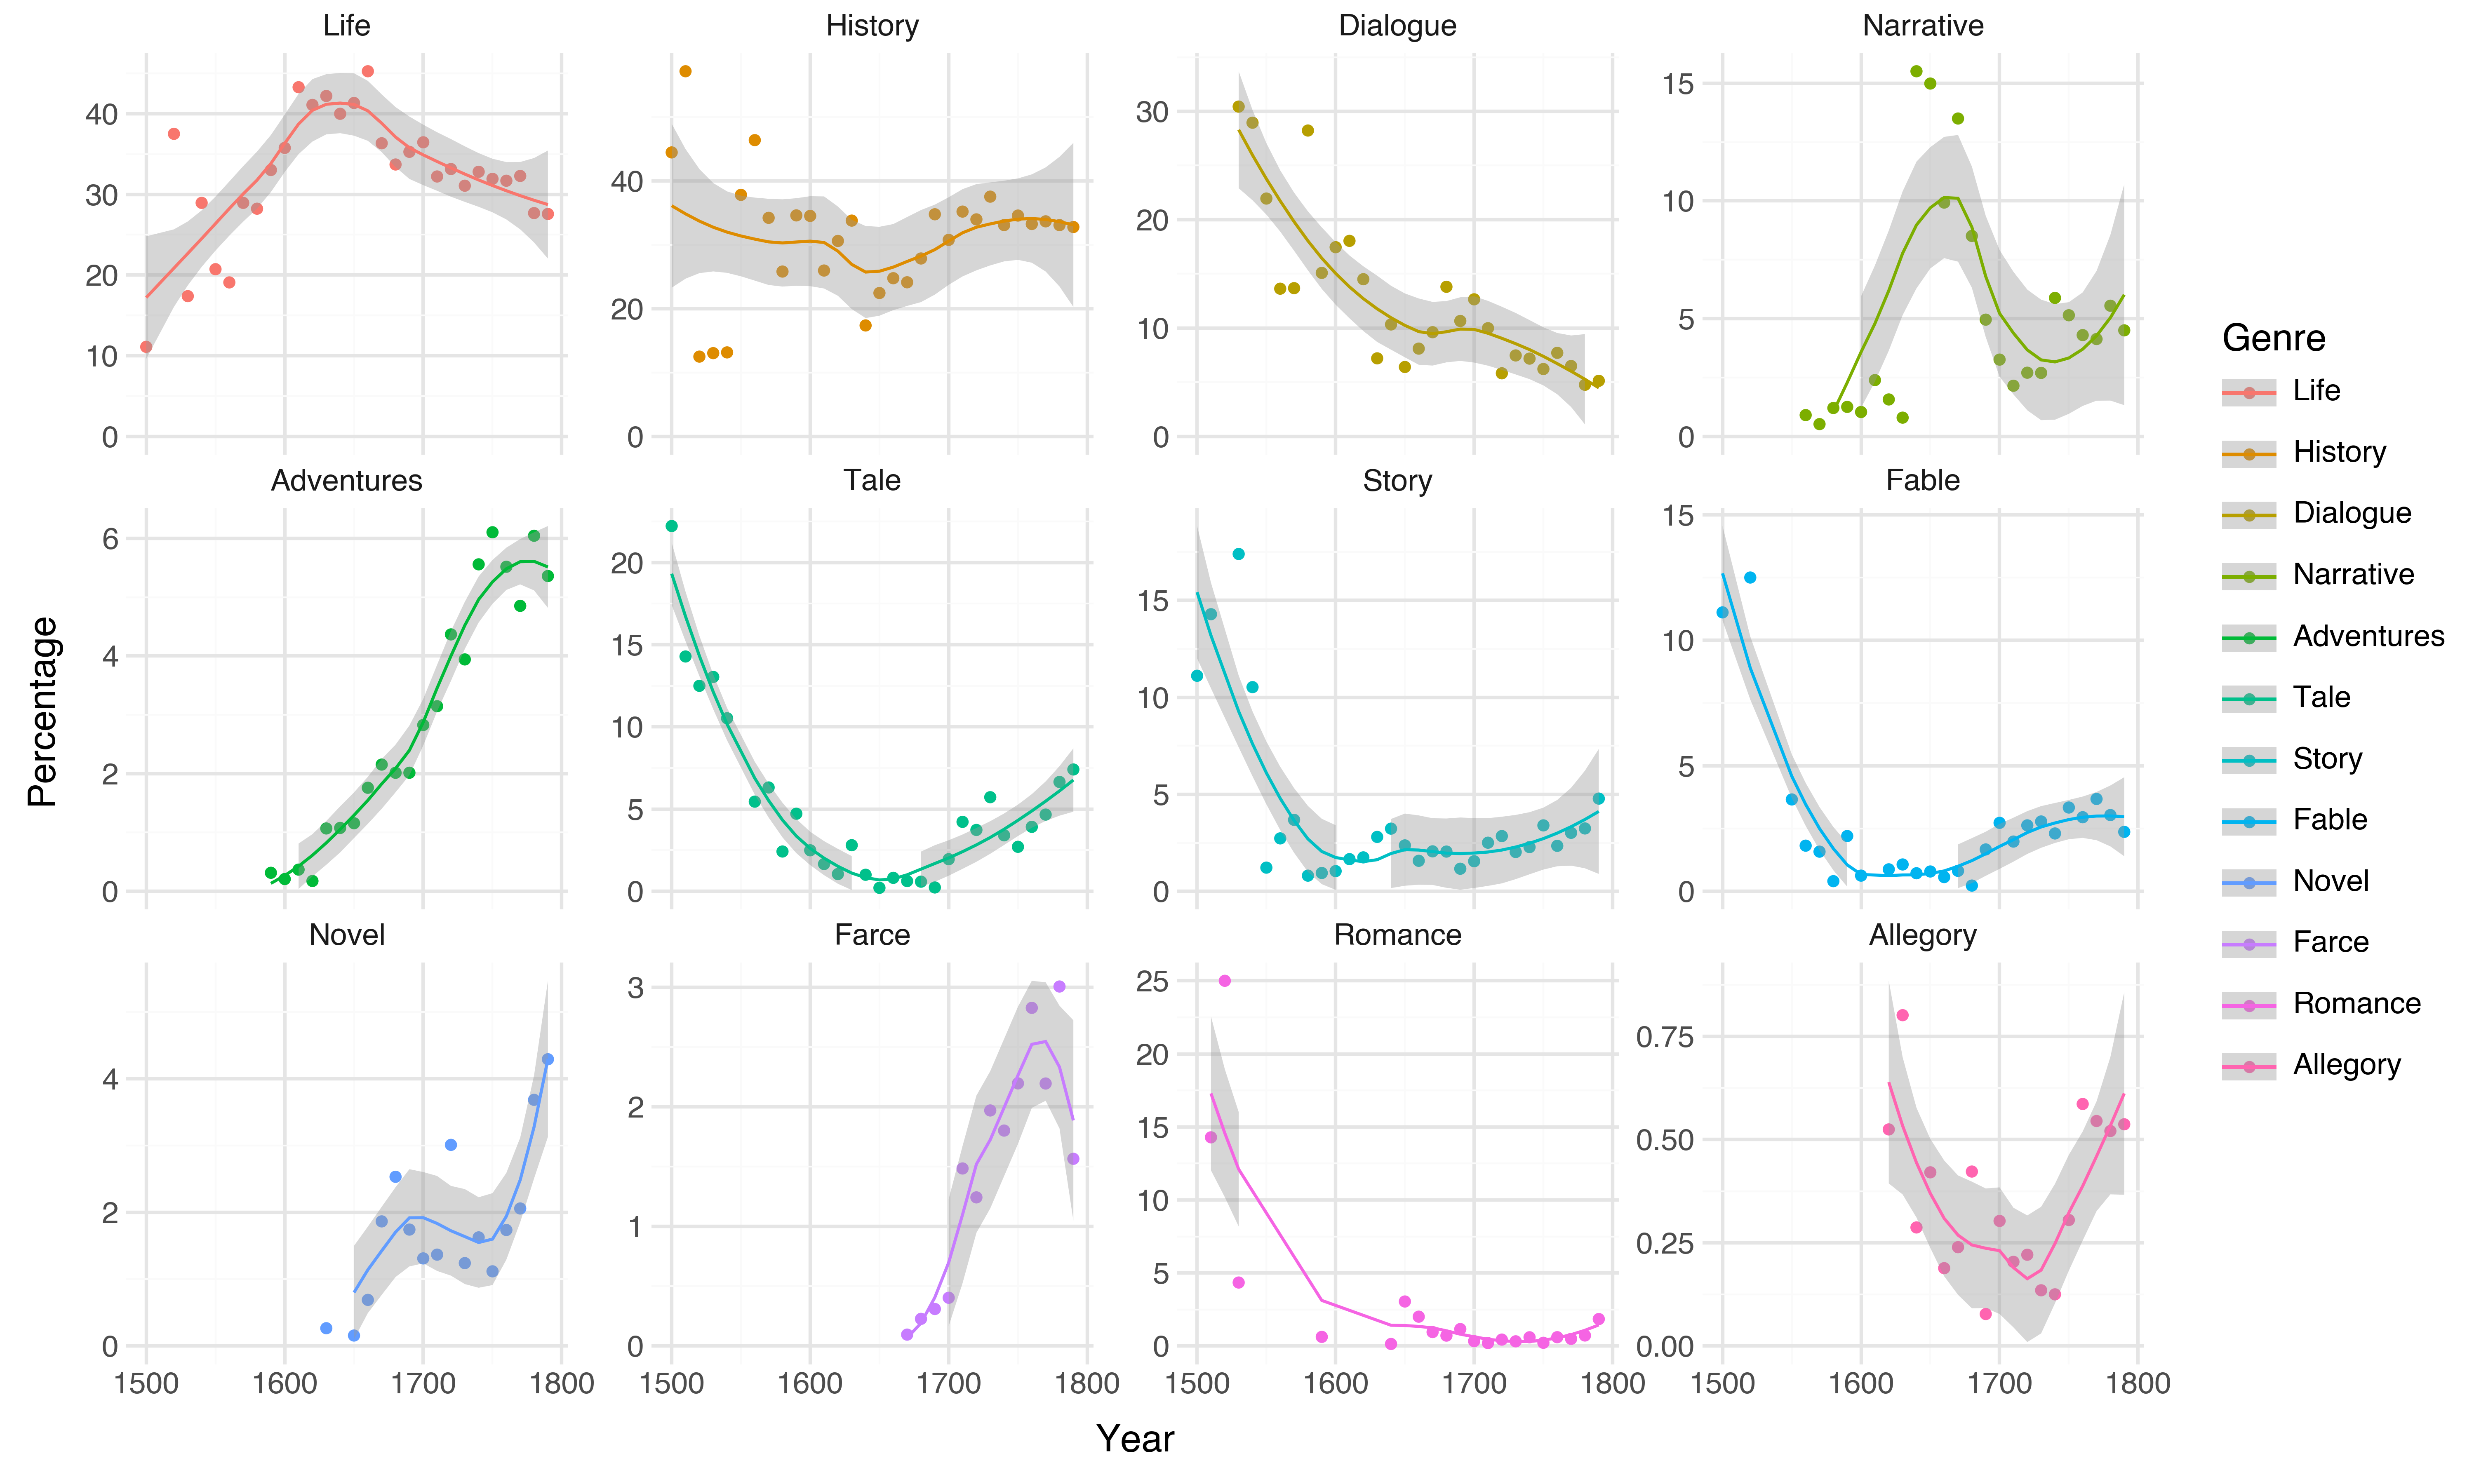

In [370]:
fig = (
    p9.ggplot(figdf.query('count>0'), p9.aes(x=yearcol, y='pct', color='genre_genre'))
    + p9.geom_point(size=1)
    # + p9.geom_line(size=.5)
    + p9.geom_smooth(method='loess', size=.5)
    + p9.theme_minimal()
    + p9.labs(x='Year', y='Percentage')
    + p9.scale_color_discrete(name='Genre')
    + p9.facet_wrap('~genre_genre', scales='free_y')
    # + p9.facet_wrap('~genre_genre')
    # + p9.scale_y_log10()
    + p9.scale_y_continuous(limits=[0,None])
)
fig